## import libraries

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("All libraries imported successfully")

All libraries imported successfully


## Create a sample dataset quickly

In [2]:
data = {
    "text": [
        "Government announces new education policy for public schools",
        "Scientists publish new climate research in international journal",
        "Local hospital opens new emergency treatment center",
        "University introduces new scholarship program for students",
        "Central bank releases annual economic report",
        "Election commission announces official voting schedule",
        "Researchers develop improved solar energy technology",
        "City authority begins construction of new public road",
        "Health ministry starts national vaccination campaign",
        "National sports team wins international tournament",

        "Aliens secretly control the world government according to hidden documents",
        "Scientists confirm humans can live forever after drinking special water",
        "Government giving every citizen free luxury cars next month",
        "Doctors discover one fruit that cures every disease instantly",
        "World will completely end tomorrow according to anonymous expert",
        "Secret machine can make anyone millionaire in one day",
        "NASA confirms moon is actually made of artificial material",
        "Eating chocolate guarantees perfect exam scores scientists claim",
        "New phone app can read everyone's mind from any distance",
        "Unknown website claims all banks will close permanently tomorrow"
    ],

    "label": [
        "REAL", "REAL", "REAL", "REAL", "REAL",
        "REAL", "REAL", "REAL", "REAL", "REAL",

        "FAKE", "FAKE", "FAKE", "FAKE", "FAKE",
        "FAKE", "FAKE", "FAKE", "FAKE", "FAKE"
    ]
}

df = pd.DataFrame(data)

df.head()

,text,label
0,Government announces new education policy for ...,REAL
1,Scientists publish new climate research in int...,REAL
2,Local hospital opens new emergency treatment c...,REAL
3,University introduces new scholarship program ...,REAL
4,Central bank releases annual economic report,REAL


## Clean the text

In [25]:
def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Keep English + Nepali characters
    text = re.sub(
        r"[^a-zA-Z\u0900-\u097F\s]",
        " ",
        text
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text", "label"]].head()

,text,clean_text,label
0,Government announces new education policy for ...,government announces new education policy for ...,REAL
1,Scientists publish new climate research in int...,scientists publish new climate research in int...,REAL
2,Local hospital opens new emergency treatment c...,local hospital opens new emergency treatment c...,REAL
3,University introduces new scholarship program ...,university introduces new scholarship program ...,REAL
4,Central bank releases annual economic report,central bank releases annual economic report,REAL


In [26]:
english_text = "Government announces new education policy."

nepali_text = "सरकारले नयाँ शिक्षा नीति सार्वजनिक गरेको छ।"

print(clean_text(english_text))
print(clean_text(nepali_text))

government announces new education policy
सरकारले नयाँ शिक्षा नीति सार्वजनिक गरेको छ।


In [27]:
nepali_data = pd.DataFrame({
    "text": [
        "सरकारले नयाँ शिक्षा नीति सार्वजनिक गरेको छ",
        "निर्वाचन आयोगले मतदानको मिति घोषणा गरेको छ",
        "अस्पतालले नयाँ आकस्मिक सेवा सुरु गरेको छ",
        "विश्वविद्यालयले नयाँ छात्रवृत्ति कार्यक्रम घोषणा गरेको छ",
        "राष्ट्र बैंकले वार्षिक आर्थिक प्रतिवेदन सार्वजनिक गरेको छ",

        "एउटा फल खाएपछि सबै रोग तुरुन्त निको हुन्छ",
        "एक दिनमै करोडपति बनाउने गोप्य मेसिन फेला परेको छ",
        "वैज्ञानिकहरूले पानी पिएर अमर हुन सकिने पुष्टि गरेका छन्",
        "मोबाइल एपले टाढाबाट सबैको दिमाग पढ्न सक्छ",
        "भोलिदेखि संसारका सबै बैंक सधैंका लागि बन्द हुनेछन्"
    ],

    "label": [
        "REAL",
        "REAL",
        "REAL",
        "REAL",
        "REAL",

        "FAKE",
        "FAKE",
        "FAKE",
        "FAKE",
        "FAKE"
    ]
})

## Merge with your existing dataset

In [28]:
df = pd.concat(
    [df[["text", "label"]], nepali_data],
    ignore_index=True
)

df["clean_text"] = df["text"].apply(clean_text)

print("Total records:", len(df))
df.tail(10)

Total records: 30


,text,label,clean_text
20,सरकारले नयाँ शिक्षा नीति सार्वजनिक गरेको छ,REAL,सरकारले नयाँ शिक्षा नीति सार्वजनिक गरेको छ
21,निर्वाचन आयोगले मतदानको मिति घोषणा गरेको छ,REAL,निर्वाचन आयोगले मतदानको मिति घोषणा गरेको छ
22,अस्पतालले नयाँ आकस्मिक सेवा सुरु गरेको छ,REAL,अस्पतालले नयाँ आकस्मिक सेवा सुरु गरेको छ
23,विश्वविद्यालयले नयाँ छात्रवृत्ति कार्यक्रम घोष...,REAL,विश्वविद्यालयले नयाँ छात्रवृत्ति कार्यक्रम घोष...
24,राष्ट्र बैंकले वार्षिक आर्थिक प्रतिवेदन सार्वज...,REAL,राष्ट्र बैंकले वार्षिक आर्थिक प्रतिवेदन सार्वज...
25,एउटा फल खाएपछि सबै रोग तुरुन्त निको हुन्छ,FAKE,एउटा फल खाएपछि सबै रोग तुरुन्त निको हुन्छ
26,एक दिनमै करोडपति बनाउने गोप्य मेसिन फेला परेको छ,FAKE,एक दिनमै करोडपति बनाउने गोप्य मेसिन फेला परेको छ
27,वैज्ञानिकहरूले पानी पिएर अमर हुन सकिने पुष्टि ...,FAKE,वैज्ञानिकहरूले पानी पिएर अमर हुन सकिने पुष्टि ...
28,मोबाइल एपले टाढाबाट सबैको दिमाग पढ्न सक्छ,FAKE,मोबाइल एपले टाढाबाट सबैको दिमाग पढ्न सक्छ
29,भोलिदेखि संसारका सबै बैंक सधैंका लागि बन्द हुन...,FAKE,भोलिदेखि संसारका सबै बैंक सधैंका लागि बन्द हुन...


## Train/test split

In [33]:
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 42
Testing samples: 18


## Logistic Regression with TF-IDF

In [34]:
logistic_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    max_features=10000
)
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000
        )
    )
])

logistic_model.fit(
    X_train,
    y_train
)

logistic_predictions = logistic_model.predict(
    X_test
)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print(
    "Logistic Regression Accuracy:",
    round(logistic_accuracy * 100, 2),
    "%"
)

Logistic Regression Accuracy: 100.0 %


## Classification report

In [35]:
print(
    classification_report(
        y_test,
        logistic_predictions
    )
)

              precision    recall  f1-score   support

        FAKE       1.00      1.00      1.00         9
        REAL       1.00      1.00      1.00         9

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



## Naive Bayes

In [36]:
naive_bayes_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    max_features=10000
)
    ),
    (
        "classifier",
        MultinomialNB()
    )
])

naive_bayes_model.fit(
    X_train,
    y_train
)

nb_predictions = naive_bayes_model.predict(
    X_test
)

nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

print(
    "Naive Bayes Accuracy:",
    round(nb_accuracy * 100, 2),
    "%"
)

Naive Bayes Accuracy: 88.89 %


## Linear SVM

In [37]:
svm_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    max_features=10000
)
    ),
    (
        "classifier",
        LinearSVC()
    )
])

svm_model.fit(
    X_train,
    y_train
)

svm_predictions = svm_model.predict(
    X_test
)

svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

print(
    "Linear SVM Accuracy:",
    round(svm_accuracy * 100, 2),
    "%"
)

Linear SVM Accuracy: 100.0 %


## Random Forest

In [38]:
random_forest_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    max_features=10000
)
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=150,
            random_state=42
        )
    )
])

random_forest_model.fit(
    X_train,
    y_train
)

rf_predictions = random_forest_model.predict(
    X_test
)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print(
    "Random Forest Accuracy:",
    round(rf_accuracy * 100, 2),
    "%"
)

Random Forest Accuracy: 100.0 %


## Compare models

In [39]:
results = {
    "Logistic Regression": logistic_accuracy,
    "Naive Bayes": nb_accuracy,
    "Linear SVM": svm_accuracy,
    "Random Forest": rf_accuracy
}

for model_name, accuracy in results.items():
    print(
        model_name,
        ":",
        round(accuracy * 100, 2),
        "%"
    )

Logistic Regression : 100.0 %
Naive Bayes : 88.89 %
Linear SVM : 100.0 %
Random Forest : 100.0 %


## Find best model

In [40]:
best_model_name = max(results, key=results.get)

print("Best Model:", best_model_name)
print(
    "Best Accuracy:",
    round(results[best_model_name] * 100, 2),
    "%"
)

Best Model: Logistic Regression
Best Accuracy: 100.0 %


## Accuracy comparison graph

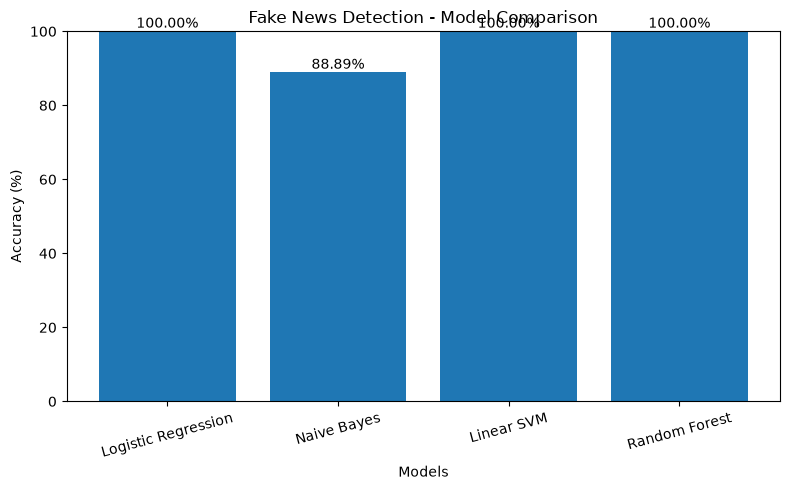

In [41]:
model_names = list(results.keys())
accuracies = [results[name] * 100 for name in model_names]

plt.figure(figsize=(8, 5))

plt.bar(
    model_names,
    accuracies
)

plt.title("Fake News Detection - Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

for i, accuracy in enumerate(accuracies):
    plt.text(
        i,
        accuracy + 1,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

## Confusion matrix

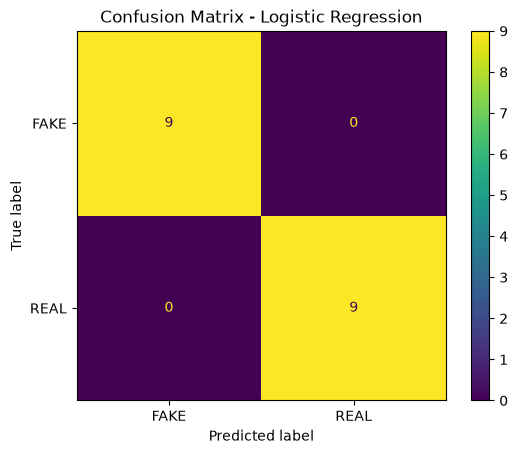

In [42]:
if best_model_name == "Logistic Regression":
    best_predictions = logistic_predictions

elif best_model_name == "Naive Bayes":
    best_predictions = nb_predictions

elif best_model_name == "Linear SVM":
    best_predictions = svm_predictions

else:
    best_predictions = rf_predictions


ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_predictions
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.show()

## Save the best model

In [43]:
import joblib

if best_model_name == "Logistic Regression":
    best_model = logistic_model

elif best_model_name == "Naive Bayes":
    best_model = naive_bayes_model

elif best_model_name == "Linear SVM":
    best_model = svm_model

else:
    best_model = random_forest_model


joblib.dump(
    best_model,
    "fake_news_model.pkl"
)

print(
    "Model saved successfully as fake_news_model.pkl"
)

Model saved successfully as fake_news_model.pkl


## model comparison graph

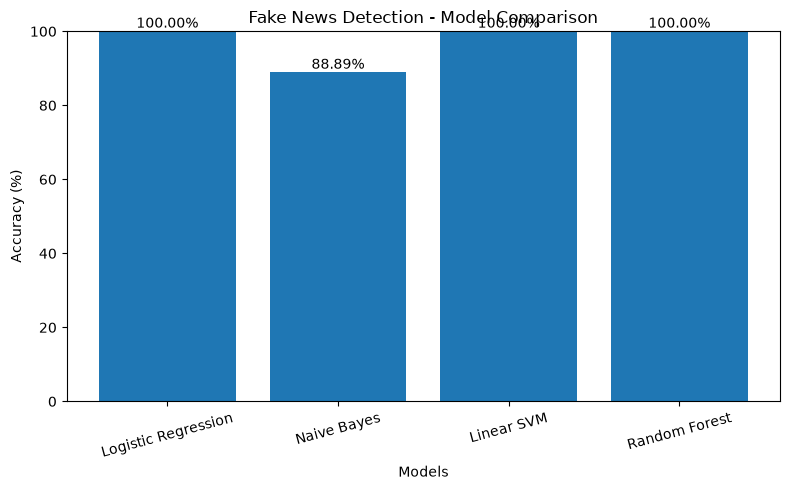

In [44]:
import os

os.makedirs("screenshots", exist_ok=True)

model_names = list(results.keys())
accuracies = [results[name] * 100 for name in model_names]

plt.figure(figsize=(8, 5))

plt.bar(
    model_names,
    accuracies
)

plt.title("Fake News Detection - Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

for i, accuracy in enumerate(accuracies):
    plt.text(
        i,
        accuracy + 1,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    "screenshots/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## confusion matrix:

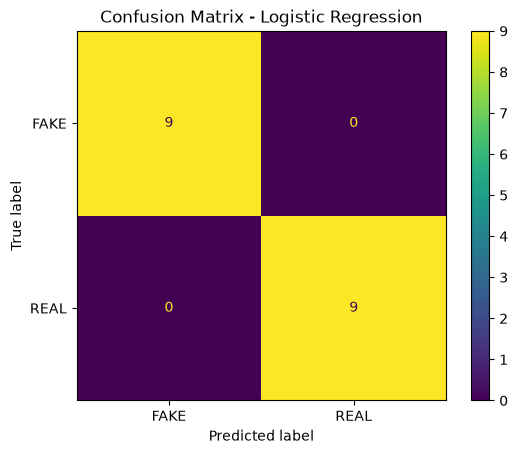

In [45]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_predictions
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.savefig(
    "screenshots/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Manual fake news test

In [46]:
sample_news = """
Government announces a new scholarship program for engineering students.
"""

cleaned_news = clean_text(sample_news)

prediction = best_model.predict([cleaned_news])[0]

print("Prediction:", prediction)

Prediction: REAL


## Test with a fake-looking statement

In [47]:
sample_news_2 = """
Scientists confirm that drinking one special juice makes humans live forever.
"""

cleaned_news_2 = clean_text(sample_news_2)

prediction_2 = best_model.predict([cleaned_news_2])[0]

print("Prediction:", prediction_2)

Prediction: FAKE


## Create prediction helper function

In [48]:
def predict_news(news_text):

    cleaned = clean_text(news_text)

    prediction = best_model.predict([cleaned])[0]

    result = {
        "News": news_text,
        "Prediction": prediction
    }

    return result

In [49]:
predict_news(
    "Election commission announces the official voting schedule."
)

{'News': 'Election commission announces the official voting schedule.',
 'Prediction': 'REAL'}

## Save test predictions

In [50]:
test_cases = [
    "Government launches a new education policy for public schools.",
    "Scientists prove humans can become invisible by drinking water.",
    "Local hospital opens a new emergency treatment center.",
    "Secret machine guarantees anyone can become a millionaire overnight."
]

test_results = []

for news in test_cases:

    result = predict_news(news)

    test_results.append(result)

test_df = pd.DataFrame(test_results)

test_df.to_csv(
    "fake_news_test_results.csv",
    index=False
)

test_df

,News,Prediction
0,Government launches a new education policy for...,REAL
1,Scientists prove humans can become invisible b...,FAKE
2,Local hospital opens a new emergency treatment...,REAL
3,Secret machine guarantees anyone can become a ...,FAKE


In [51]:
nepali_real_test = """
सरकारले नयाँ शिक्षा नीति सार्वजनिक गरेको छ।
"""

nepali_fake_test = """
एउटा फल खाएपछि सबै रोग तुरुन्त निको हुन्छ।
"""

print(
    "Nepali Real Test:",
    predict_news(nepali_real_test)
)

print(
    "Nepali Fake Test:",
    predict_news(nepali_fake_test)
)

Nepali Real Test: {'News': '\nसरकारले नयाँ शिक्षा नीति सार्वजनिक गरेको छ।\n', 'Prediction': 'REAL'}
Nepali Fake Test: {'News': '\nएउटा फल खाएपछि सबै रोग तुरुन्त निको हुन्छ।\n', 'Prediction': 'FAKE'}


## add more Nepali REAL and FAKE examples

In [31]:
extra_nepali_data = pd.DataFrame({
    "text": [

        # REAL
        "सरकारले आगामी आर्थिक वर्षको बजेट सार्वजनिक गरेको छ",
        "शिक्षा मन्त्रालयले विद्यालयको नयाँ शैक्षिक क्यालेन्डर सार्वजनिक गरेको छ",
        "नेपाल राष्ट्र बैंकले नयाँ मौद्रिक नीति सार्वजनिक गरेको छ",
        "मौसम पूर्वानुमान महाशाखाले वर्षाको सम्भावना रहेको जनाएको छ",
        "विश्वविद्यालयले स्नातक तहको परीक्षा तालिका प्रकाशित गरेको छ",
        "स्वास्थ्य मन्त्रालयले खोप अभियान सुरु गरेको जनाएको छ",
        "निर्वाचन आयोगले मतदाता नामावली अद्यावधिक गर्ने सूचना जारी गरेको छ",
        "नगरपालिकाले नयाँ सडक निर्माण कार्य सुरु गरेको छ",
        "प्रहरीले घटनाबारे अनुसन्धान भइरहेको जनाएको छ",
        "अस्पतालले नयाँ उपचार सेवा सञ्चालनमा ल्याएको छ",
        "सरकारले सार्वजनिक बिदाको सूचना जारी गरेको छ",
        "विश्वविद्यालयले नयाँ छात्रवृत्ति कार्यक्रम घोषणा गरेको छ",
        "नेपाल विद्युत प्राधिकरणले विद्युत सेवा सुधार योजना सार्वजनिक गरेको छ",
        "स्थानीय तहले विकास आयोजनाको बजेट स्वीकृत गरेको छ",
        "पर्यटन बोर्डले पर्यटक आगमनसम्बन्धी तथ्यांक सार्वजनिक गरेको छ",

        # FAKE
        "एक गिलास पानी पिएपछि मानिस कहिल्यै बूढो हुँदैन",
        "एउटा मोबाइल एपले मानिसको दिमाग पढ्न सक्छ",
        "वैज्ञानिकहरूले मानिसलाई अदृश्य बनाउने औषधि बनाएका छन्",
        "एउटा फल खाएपछि सबै प्रकारका रोग निको हुन्छन्",
        "भोलिदेखि संसारका सबै बैंक सधैंका लागि बन्द हुनेछन्",
        "एक दिनमै करोडपति बनाउने गोप्य मेसिन बजारमा आएको छ",
        "चन्द्रमा वास्तवमा प्लास्टिकबाट बनेको वैज्ञानिकहरूले पुष्टि गरेका छन्",
        "मोबाइल चार्ज गर्दा पैसा आफै खातामा जम्मा हुन्छ",
        "एउटा मन्त्र पढेपछि कुनै पनि परीक्षा स्वतः पास हुन्छ",
        "सरकारले सबै नागरिकलाई नि:शुल्क महँगो कार दिने घोषणा गरेको छ",
        "मानिसले खाना नखाई दस वर्षसम्म बाँच्न सक्ने प्रमाणित भएको छ",
        "एउटा चिया पिएपछि शरीरका सबै रोग समाप्त हुन्छन्",
        "नयाँ एपले भविष्यमा हुने सबै घटनाहरू सही बताउँछ",
        "वैज्ञानिकहरूले मानिसलाई उड्न सक्ने औषधि बनाएका छन्",
        "एक रात सुत्दा मानिसको उचाइ एक फिट बढ्ने अनुसन्धानले देखाएको छ"
    ],

    "label": [
        "REAL","REAL","REAL","REAL","REAL",
        "REAL","REAL","REAL","REAL","REAL",
        "REAL","REAL","REAL","REAL","REAL",

        "FAKE","FAKE","FAKE","FAKE","FAKE",
        "FAKE","FAKE","FAKE","FAKE","FAKE",
        "FAKE","FAKE","FAKE","FAKE","FAKE"
    ]
})

In [32]:
df = pd.concat(
    [df[["text", "label"]], extra_nepali_data],
    ignore_index=True
)

df["clean_text"] = df["text"].apply(clean_text)

print(df["label"].value_counts())
print("Total records:", len(df))

label
REAL    30
FAKE    30
Name: count, dtype: int64
Total records: 60


In [52]:
nepali_real_test = """
सरकारले नयाँ शिक्षा नीति सार्वजनिक गरेको छ।
"""

nepali_fake_test = """
एउटा फल खाएपछि सबै रोग तुरुन्त निको हुन्छ।
"""

print(
    "Nepali Real Test:",
    predict_news(nepali_real_test)
)

print(
    "Nepali Fake Test:",
    predict_news(nepali_fake_test)
)

Nepali Real Test: {'News': '\nसरकारले नयाँ शिक्षा नीति सार्वजनिक गरेको छ।\n', 'Prediction': 'REAL'}
Nepali Fake Test: {'News': '\nएउटा फल खाएपछि सबै रोग तुरुन्त निको हुन्छ।\n', 'Prediction': 'FAKE'}
